In [1]:
import requests
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = requests.get("https://tabular-api.data.gouv.fr/api/resources/41744167-0321-4e22-8e4f-6974522d5185/data/json/")
data

<Response [200]>

Aperçu de la base de données :

In [2]:
results = json.loads(data.text)
df = pd.DataFrame(results)
df.head()

,__id,CODGEO_25,LIBGEO_25,pp_vacant_25,pp_vacant_plus_2ans_25,pp_total_24,pp_vacant_24,pp_vacant_plus_2ans_24,pp_total_23,pp_vacant_23,...,pp_vacant_plus_2ans_21,pp_total_20,pp_vacant_20,pp_vacant_plus_2ans_20,EPCI_25,LIB_EPCI_25,DEP,LIB_DEP,REG,LIB_REG
0,1,01001,L'Abergement-Clémenciat,s,s,358,15,s,355,15,...,s,339,20,s,200069193,Communauté de communes de la Dombes,01,Ain,84,Auvergne-Rhône-Alpes
1,2,01002,L'Abergement-de-Varey,s,s,180,11,s,180,s,...,s,181,13,s,240100883,Communauté de communes de la Plaine de l'Ain,01,Ain,84,Auvergne-Rhône-Alpes
2,3,01004,Ambérieu-en-Bugey,374,207,5949,628,200,5918,626,...,190,5776,679,163,240100883,Communauté de communes de la Plaine de l'Ain,01,Ain,84,Auvergne-Rhône-Alpes
3,4,01005,Ambérieux-en-Dombes,28,13,809,61,s,795,39,...,s,693,38,s,200042497,Communauté de communes Dombes Saône Vallée,01,Ain,84,Auvergne-Rhône-Alpes
4,5,01006,Ambléon,s,s,s,s,s,s,s,...,s,s,s,s,200040350,Communauté de communes Bugey Sud,01,Ain,84,Auvergne-Rhône-Alpes


In [3]:
df[df=='s'] = 0
df.head()

,__id,CODGEO_25,LIBGEO_25,pp_vacant_25,pp_vacant_plus_2ans_25,pp_total_24,pp_vacant_24,pp_vacant_plus_2ans_24,pp_total_23,pp_vacant_23,...,pp_vacant_plus_2ans_21,pp_total_20,pp_vacant_20,pp_vacant_plus_2ans_20,EPCI_25,LIB_EPCI_25,DEP,LIB_DEP,REG,LIB_REG
0,1,01001,L'Abergement-Clémenciat,0,0,358,15,0,355,15,...,0,339,20,0,200069193,Communauté de communes de la Dombes,01,Ain,84,Auvergne-Rhône-Alpes
1,2,01002,L'Abergement-de-Varey,0,0,180,11,0,180,0,...,0,181,13,0,240100883,Communauté de communes de la Plaine de l'Ain,01,Ain,84,Auvergne-Rhône-Alpes
2,3,01004,Ambérieu-en-Bugey,374,207,5949,628,200,5918,626,...,190,5776,679,163,240100883,Communauté de communes de la Plaine de l'Ain,01,Ain,84,Auvergne-Rhône-Alpes
3,4,01005,Ambérieux-en-Dombes,28,13,809,61,0,795,39,...,0,693,38,0,200042497,Communauté de communes Dombes Saône Vallée,01,Ain,84,Auvergne-Rhône-Alpes
4,5,01006,Ambléon,0,0,0,0,0,0,0,...,0,0,0,0,200040350,Communauté de communes Bugey Sud,01,Ain,84,Auvergne-Rhône-Alpes


La ville qui a le plus de logements vacants en 2025 :

In [5]:
df['pp_vacant_25'] = df['pp_vacant_25'].astype(int)

In [ ]:
df[['LIBGEO_25','pp_vacant_25']][df['pp_vacant_25'] == max(df['pp_vacant_25'])]

,LIBGEO_25,pp_vacant_25
11782,Toulouse,18647


Le nombre de logements vacants par région en 2025 :

In [7]:
df.groupby(["LIB_REG"]).agg({"pp_vacant_25": "sum"})

,pp_vacant_25
LIB_REG,
Auvergne-Rhône-Alpes,313993
Bourgogne-Franche-Comté,128471
Bretagne,116685
Centre-Val de Loire,103011
Corse,22801
Grand Est,200547
Guadeloupe,19995
Guyane,10363
Hauts-de-France,155340


La région qui a le plus de logements vacants en 2025 :

In [8]:
regions = df.groupby(["LIB_REG"]).agg({"pp_vacant_25": "sum"})
regions[regions['pp_vacant_25']==max(regions['pp_vacant_25'])]

,pp_vacant_25
LIB_REG,
Auvergne-Rhône-Alpes,313993


Ou en une ligne :

In [9]:
df.groupby(["LIB_REG"]).agg({"pp_vacant_25": "sum"}).sort_values(["pp_vacant_25"],ascending=False).head(1)

,pp_vacant_25
LIB_REG,
Auvergne-Rhône-Alpes,313993


Evolution du nombre de logements vacants entre 2020 et 2025 :

On crée un DataFrame des logements vacants par région :

In [16]:
df['pp_vacant_20'] = df['pp_vacant_20'].astype(int)
df['pp_vacant_21'] = df['pp_vacant_21'].astype(int)
df['pp_vacant_22'] = df['pp_vacant_22'].astype(int)
df['pp_vacant_23'] = df['pp_vacant_23'].astype(int)
df['pp_vacant_24'] = df['pp_vacant_24'].astype(int)

df_reg = df.groupby(["LIB_REG"]).agg({"pp_vacant_25": "sum","pp_vacant_24": "sum","pp_vacant_23": "sum","pp_vacant_22": "sum","pp_vacant_21": "sum","pp_vacant_20": "sum"})
df_reg

,pp_vacant_25,pp_vacant_24,pp_vacant_23,pp_vacant_22,pp_vacant_21,pp_vacant_20
LIB_REG,,,,,,
Auvergne-Rhône-Alpes,313993,489613,497241,472580,487938,488694
Bourgogne-Franche-Comté,128471,170954,171630,170051,169213,170656
Bretagne,116685,177285,178791,175556,184125,185611
Centre-Val de Loire,103011,139475,144170,136484,140864,139572
Corse,22801,38523,40432,39044,36686,37542
Grand Est,200547,289363,294625,284297,291351,296613
Guadeloupe,19995,39795,45992,35132,40017,39644
Guyane,10363,16139,19205,15078,13585,14296
Hauts-de-France,155340,230031,234906,222155,234517,238146


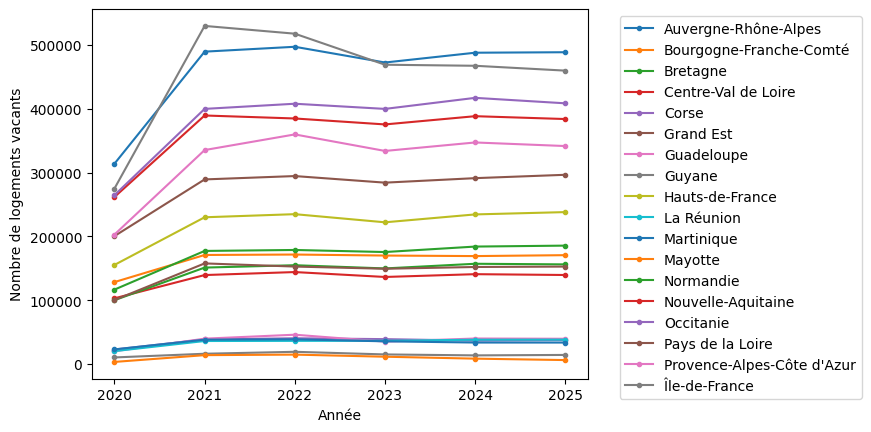

In [17]:
log_vac_tot = [df.agg({"pp_vacant_20": "sum"}),df.agg({"pp_vacant_21": "sum"}),df.agg({"pp_vacant_22": "sum"}),df.agg({"pp_vacant_23": "sum"}),df.agg({"pp_vacant_24": "sum"}),df.agg({"pp_vacant_25": "sum"})]

fig,ax = plt.subplots()
annees = [2020,2021,2022,2023,2024,2025]
#plt.plot(annees,log_vac_tot,'.-')
for i in range(len(df_reg)):
    plt.plot(annees,df_reg.iloc[i],'.-',label=str(df_reg.index[i]))
plt.xlabel('Année')
plt.ylabel('Nombre de logements vacants')
plt.legend()
ax.ticklabel_format(style='plain')
ax.legend(bbox_to_anchor=(1.05, 1),loc='upper left')